# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [8]:
# TODO
print(f"Số cột trong table là: {len(df.columns)}. Số dòng dữ liệu trong table là: {df.shape[0]}")
print(f"Tên các cột trong table là: {" | ".join(df.columns.to_list())}")
df.dtypes


Số cột trong table là: 7. Số dòng dữ liệu trong table là: 1338
Tên các cột trong table là: age | sex | bmi | children | smoker | region | charges


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

## A.2. Missing values & Duplicate data

In [13]:
# TODO
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Không có dòng nào thiếu dữ liệu!")
print()
print("Duplicate row (toàn bộ): ", df.duplicated().sum())

Không có dòng nào thiếu dữ liệu!

Duplicate row (toàn bộ):  1


## A.3. Invalid values

In [15]:
# TODO
valid_sex = ['female', 'male']
valid_smoker = ['yes', 'no']

invalid_conditions = (

    (df['age'] <= 0) | (df['age'] % 1 != 0) |
    
    (~df['sex'].isin(valid_sex)) |

    (~df['smoker'].isin(valid_smoker)) |
    
    (df['bmi'] <= 0) |
    
    (df['children'] < 0) | (df['children'] % 1 != 0) |
    
    (df['charges'] <= 0)
)

invalid_rows = df[invalid_conditions]

if not invalid_rows.empty:
    print(f"Phát hiện {len(invalid_rows)} dòng dữ liệu không hợp lệ:")
    print(invalid_rows)
else:
    print("Dữ liệu hoàn toàn hợp lệ về mặt logic!")


Dữ liệu hoàn toàn hợp lệ về mặt logic!


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [17]:
# TODO
condition=[
    df['bmi'] < 25,
    (df['bmi'] >= 25) & (df['bmi'] <= 30),
    df['bmi'] > 30
]

label = ['Normal', 'Overweight', 'Obese']

df['bmi_group'] = np.select(condition, label, default='Unknow')
df

,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,Obese
1334,18,female,31.920,0,no,northeast,2205.98080,Obese
1335,18,female,36.850,0,no,southeast,1629.83350,Obese
1336,21,female,25.800,0,no,southwest,2007.94500,Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [19]:
# TODO
for col in ['bmi', 'charges']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")

print("\n---")
print("Mode sex:", df['sex'].mode()[0])
print("Mode smoker:", df['smoker'].mode()[0])
print("Mode region:", df['region'].mode()[0])

bmi: Mean=30.66, Median=30.40, Mode=32.30
charges: Mean=13270.42, Median=9382.03, Mode=1639.56

---
Mode sex: male
Mode smoker: no
Mode region: southeast


## Group 2 — Dispersion

In [20]:
# TODO
for col in ['bmi', 'charges']:
    s = df[col]
    range_ = s.max() - s.min()
    std_ = s.std() 
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1   
    cv = std_ / s.mean()
    
    print(f"--- {col.upper()} ---")
    print(f"Range = {range_:.2f}")
    print(f"Std = {std_:.2f}")
    print(f"IQR = {iqr:.2f}")
    print(f"CV = {cv:.2f}\n")

--- BMI ---
Range = 37.17
Std = 6.10
IQR = 8.40
CV = 0.20

--- CHARGES ---
Range = 62648.55
Std = 12110.01
IQR = 11899.63
CV = 0.91



## Group 3 — Location and Shape

--- BMI ---
P25=26.30, P50=30.40, P75=34.69
Skewness=0.28, Kurtosis=-0.06

--- CHARGES ---
P25=4740.29, P50=9382.03, P75=16639.91
Skewness=1.51, Kurtosis=1.60



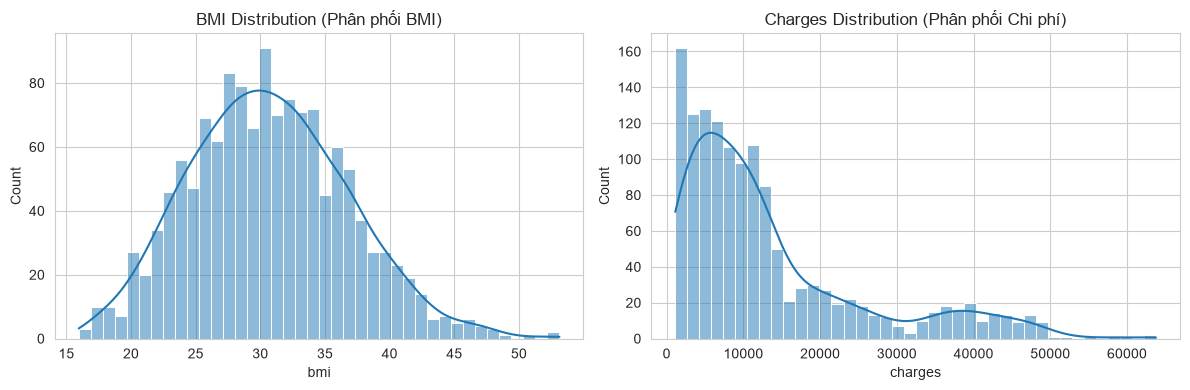

In [21]:
# TODO
for col in ['bmi', 'charges']:
    s = df[col].dropna()
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    
    print(f"--- {col.upper()} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}\n")

# Trực quan hóa bằng biểu đồ Histogram kèm đường cong KDE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['bmi'].dropna(), bins=40, kde=True, ax=axes[0])
axes[0].set_title('BMI Distribution (Phân phối BMI)')

sns.histplot(df['charges'].dropna(), bins=40, kde=True, ax=axes[1])
axes[1].set_title('Charges Distribution (Phân phối Chi phí)')

plt.tight_layout()
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

-> TỔNG THỂ: Chi phí trung bình của người hút thuốc cao gấp 3.80 lần so với người không hút.
--------------------------------------------------
BẢNG PHÂN TÍCH CHI TIẾT THEO VÙNG:
smoker          no       yes  ratio (Số lần gấp)
region                                          
northeast  9165.53  29673.54                3.24
northwest  8556.46  30192.00                3.53
southeast  8032.22  34845.00                4.34
southwest  8019.28  32269.06                4.02


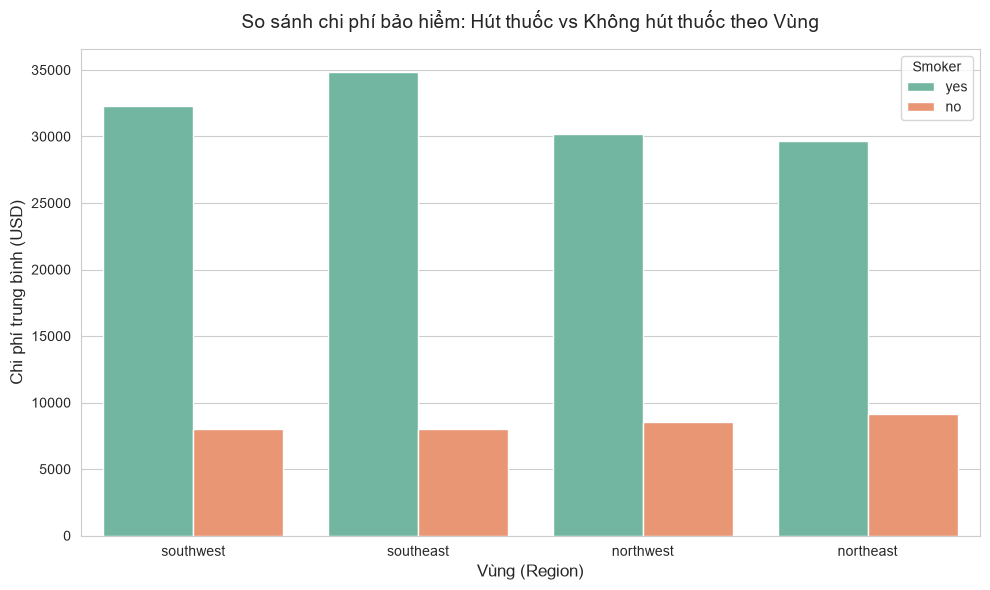

In [ ]:
# TODO
smoker_mean = df.groupby('smoker')['charges'].mean()
ratio_overall = smoker_mean['yes'] / smoker_mean['no']

print(f"-> TỔNG THỂ: Chi phí trung bình của người hút thuốc cao gấp {ratio_overall:.2f} lần so với người không hút.")
print("-" * 50)

region_smoker = df.pivot_table(
    values='charges', 
    index='region', 
    columns='smoker', 
    aggfunc='mean'
)

region_smoker['ratio (Số lần gấp)'] = region_smoker['yes'] / region_smoker['no']

print("BẢNG PHÂN TÍCH CHI TIẾT THEO VÙNG:")
print(region_smoker.round(2))

plt.figure(figsize=(10, 6))

sns.barplot(data=df, x='region', y='charges', hue='smoker', errorbar=None, palette='Set2')

plt.title('So sánh chi phí bảo hiểm: Hút thuốc vs Không hút thuốc theo Vùng', fontsize=14, pad=15)
plt.xlabel('Vùng (Region)', fontsize=12)
plt.ylabel('Chi phí trung bình (USD)', fontsize=12)
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

In [25]:
# TODO
smoker_yes = df[df['smoker'] == 'yes']
smoker_no = df[df['smoker'] == 'no']

corr_yes = smoker_yes['bmi'].corr(smoker_yes['charges'])
corr_no = smoker_no['bmi'].corr(smoker_no['charges'])

print(f"Hệ số tương quan (BMI và Charges) ở nhóm HÚT THUỐC: {corr_yes:.3f}")
print(f"Hệ số tương quan (BMI và Charges) ở nhóm KHÔNG HÚT THUỐC: {corr_no:.3f}")
print('Nhóm hút thuốc có độ tương quan giữa BMI và chi phí mạnh hơn nhóm không khút thuốc')

Hệ số tương quan (BMI và Charges) ở nhóm HÚT THUỐC: 0.806
Hệ số tương quan (BMI và Charges) ở nhóm KHÔNG HÚT THUỐC: 0.084
Nhóm hút thuốc có độ tương quan giữa BMI và chi phí mạnh hơn nhóm không khút thuốc


## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

In [ ]:
# TODO


## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

Chi phí trung bình theo từng vùng:
region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64

=> Vùng có chi phí trung bình cao nhất là 'southeast' (14735.41 USD)


C:\Users\LENOVO LECOO\AppData\Local\Temp\ipykernel_21108\240009864.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


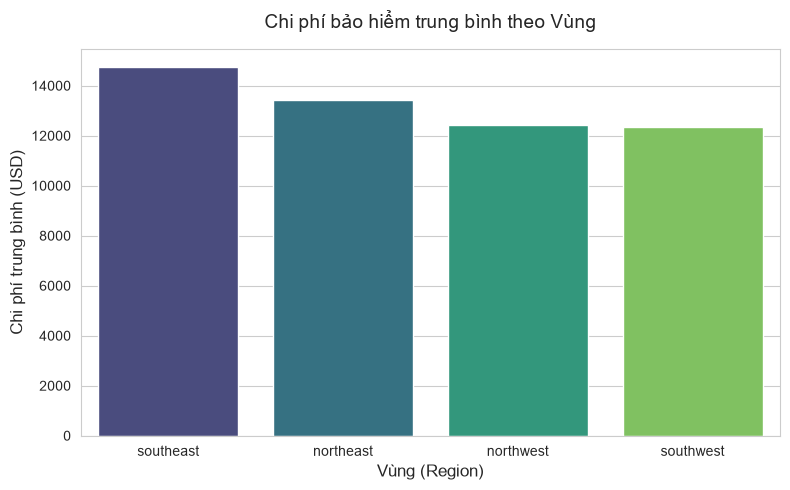

In [27]:
# TODO
region_charges = df.groupby('region')['charges'].mean().sort_values(ascending=False)
print("Chi phí trung bình theo từng vùng:")
print(region_charges)

highest_region = region_charges.index[0]
highest_cost = region_charges.iloc[0]
print(f"\n=> Vùng có chi phí trung bình cao nhất là '{highest_region}' ({highest_cost:.2f} USD)")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df, 
    x='region', 
    y='charges', 
    errorbar=None, 
    order=region_charges.index, 
    palette='viridis'
)

plt.title("Chi phí bảo hiểm trung bình theo Vùng", fontsize=14, pad=15)
plt.xlabel("Vùng (Region)", fontsize=12)
plt.ylabel("Chi phí trung bình (USD)", fontsize=12)
plt.tight_layout()
plt.show()

## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

Hệ số tương quan giữa Độ tuổi và Chi phí: 0.299


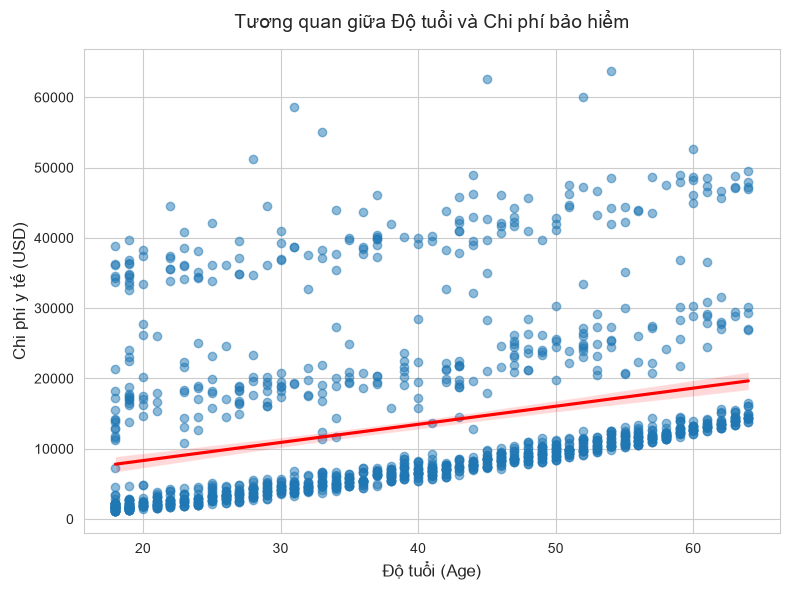

Hệ số tương quan: Kết quả khoảng 0.299. Đây là một mức độ trung bình - yếu.


In [32]:
corr_age = df['age'].corr(df['charges'])
print(f"Hệ số tương quan giữa Độ tuổi và Chi phí: {corr_age:.3f}")

plt.figure(figsize=(8, 6))
sns.regplot(
    data=df, 
    x='age', 
    y='charges', 
    scatter_kws={'alpha': 0.5}, 
    line_kws={'color': 'red'}
)

plt.title("Tương quan giữa Độ tuổi và Chi phí bảo hiểm", fontsize=14, pad=15)
plt.xlabel("Độ tuổi (Age)", fontsize=12)
plt.ylabel("Chi phí y tế (USD)", fontsize=12)
plt.tight_layout()
plt.show()

print('Hệ số tương quan: Kết quả khoảng 0.299. Đây là một mức độ trung bình - yếu.')

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

1. Phân phối chi phí bảo hiểm y tế có độ lệch phải rất mạnh, cho thấy mặt bằng giá chung bị đẩy lên đáng kể bởi một nhóm nhỏ khách hàng mang rủi ro sức khỏe lớn.
2. Trong số các biến số, tình trạng hút thuốc là yếu tố quyết định lớn nhất, khiến người hút thuốc phải gánh chịu mức phí cao gấp gần 4 lần so với người không hút.
3. Đặc biệt, sự kết hợp giữa hút thuốc và chỉ số BMI cao (béo phì) tạo ra hiệu ứng kép nghiêm trọng nhất, đẩy chi phí cá nhân lên mức đỉnh điểm trong toàn bộ hệ thống.
4. Yếu tố độ tuổi chỉ có mức tương quan dương trung bình với chi phí, đóng vai trò như một hằng số thiết lập mức phí nền tảng tăng dần đều theo quy luật lão hóa tự nhiên.
5. Cuối cùng, khu vực Đông Nam (Southeast) là nơi ghi nhận mức chi phí trung bình dẫn đầu, phản ánh sự cộng hưởng của các yếu tố rủi ro về lối sống và thể trạng đặc thù tại vùng này.